## Ground Truth Generation

In [1]:
# %pip install networkx graphviz numpy pgmpy torch matplotlib

In [2]:
import random
import graphviz
import networkx as nx
import numpy as np
import os, time
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.parameter_estimator import DiscreteBayesianEstimator

import torch
import torch.nn as nn
import pandas as pd

from tqdm import tqdm
import matplotlib.pyplot as plt
import psutil


/home/kaylin/CSprojects/Neural-Discrete-Bayesian-Network/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### DAG Generation

In [3]:
#min in-degree?
'''
def generate_dag(n, max_in_degree, max_density, seed):

    # Random topological order
    rng = random.Random(seed)
    order = [f"X_{i}" for i in range(n)]
    rng.shuffle(order)

    # Create DAG
    G = nx.DiGraph()
    G.add_nodes_from(order)
    max_edges = round(max_density*n*(n-1)/2)

    # Feasibility Check
    ceiling = sum(min(i, max_in_degree) for i in range(n))
    if max_edges > ceiling:
        print(f"warning: density {max_density} needs {max_edges} edges, but max in-degree allows only {ceiling}")
        max_edges = ceiling
        max_density = max_edges / (n*(n-1)/2)

    # Backbone - Ensure weak connectivity
    for i in range(1, n):
        child = order[i]
        parent = rng.choice(order[:i])
        G.add_edge(parent, child)

    # Extra edges
    possible_edges = [(order[i], order[j]) for j in range(n) for i in range(j)]
    rng.shuffle(possible_edges)

    for u,v in possible_edges:
        if(G.has_edge(u,v)):
            continue
        if(G.number_of_edges() >= max_edges):
            break

        G.add_edge(u,v)
        if(G.number_of_edges() / (n*(n-1)/2) >= max_density):
            G.remove_edge(u,v)
            break

    return G
'''
 

'\ndef generate_dag(n, max_in_degree, max_density, seed):\n\n    # Random topological order\n    rng = random.Random(seed)\n    order = [f"X_{i}" for i in range(n)]\n    rng.shuffle(order)\n\n    # Create DAG\n    G = nx.DiGraph()\n    G.add_nodes_from(order)\n    max_edges = round(max_density*n*(n-1)/2)\n\n    # Feasibility Check\n    ceiling = sum(min(i, max_in_degree) for i in range(n))\n    if max_edges > ceiling:\n        print(f"warning: density {max_density} needs {max_edges} edges, but max in-degree allows only {ceiling}")\n        max_edges = ceiling\n        max_density = max_edges / (n*(n-1)/2)\n\n    # Backbone - Ensure weak connectivity\n    for i in range(1, n):\n        child = order[i]\n        parent = rng.choice(order[:i])\n        G.add_edge(parent, child)\n\n    # Extra edges\n    possible_edges = [(order[i], order[j]) for j in range(n) for i in range(j)]\n    rng.shuffle(possible_edges)\n\n    for u,v in possible_edges:\n        if(G.has_edge(u,v)):\n            co

In [4]:
def gen_dag_indegree(n, k, seed):
    rng = random.Random(seed)
    order = [f"X_{i}" for i in range(n)]
    rng.shuffle(order)
    G = nx.DiGraph()
    G.add_nodes_from(order)
    for i in range(1, n):
        n_parents = min(k, i)
        for p in rng.sample(order[:i], n_parents):
            G.add_edge(p, order[i])
    return G

def gen_dag_max_indegree(n, max_k, seed):
    rng = random.Random(seed)
    order = [f"X_{i}" for i in range(n)]
    rng.shuffle(order)
    G = nx.DiGraph()
    G.add_nodes_from(order)
    for i in range(1, n):
        n_parents = rng.randint(1, min(max_k, i))
        for p in rng.sample(order[:i], n_parents):
            G.add_edge(p, order[i])
    return G

#### Test

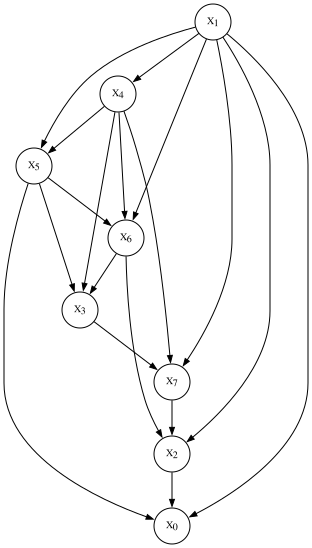

In [5]:
N_NODES = 8
CARDINALITY = 2
ALPHA = 1.0

MAX_IN_DEGREE = 3
MAX_DENSITY = 0.8

dag = gen_dag_indegree(
    n=N_NODES,
    k=MAX_IN_DEGREE,
    seed=123
)

dot = graphviz.Digraph(
    graph_attr={"rankdir": "TB"},
    node_attr={"width": "0.5", "height": "0.5", "fontsize": "10"},
    edge_attr={"arrowsize": "0.7"},
)

for u, v in dag.edges:
    dot.edge(u, v)

for i in range(N_NODES):
    node_id = f"X_{i}"
    dot.node(node_id, label=f"<X<SUB>{i}</SUB>>")

dot

### Ground Truth CPTs
Populate ground-truth CPTs from Dirichlet

In [6]:
def gen_CPTs(G, card, alpha, seed):

    rng = np.random.default_rng(seed)
    model = DiscreteBayesianNetwork(list(G.edges()))
    model.add_nodes_from(G.nodes())

    cpds = []
    for node in G.nodes():
        parents = sorted(G.predecessors(node))
        n_configs = card ** len(parents)
        vals = rng.dirichlet([alpha] * card, size=n_configs).T   # (card, n_configs)
        cpd = TabularCPD(
            variable=node, variable_card=card, values=vals,
            evidence=parents or None,
            evidence_card=[card] * len(parents) or None,
            state_names={v: list(range(card)) for v in [node] + parents},
        )
        cpds.append(cpd)
 
    model.add_cpds(*cpds)
    model.check_model()
    return model


#### Test

In [7]:
ground_truth = gen_CPTs(G=dag, card=CARDINALITY, alpha=ALPHA, seed=456)

for cpd in ground_truth.get_cpds():
    print(f"{cpd} \n")

+--------+----------+
| X_1(0) | 0.538859 |
+--------+----------+
| X_1(1) | 0.461141 |
+--------+----------+ 

+--------+---------------------+----------------------+
| X_1    | X_1(0)              | X_1(1)               |
+--------+---------------------+----------------------+
| X_4(0) | 0.32406706937795593 | 0.981314983195667    |
+--------+---------------------+----------------------+
| X_4(1) | 0.6759329306220442  | 0.018685016804333033 |
+--------+---------------------+----------------------+ 

+--------+---------------------+-----+---------------------+
| X_1    | X_1(0)              | ... | X_1(1)              |
+--------+---------------------+-----+---------------------+
| X_4    | X_4(0)              | ... | X_4(1)              |
+--------+---------------------+-----+---------------------+
| X_5(0) | 0.06863164792155352 | ... | 0.5398787090259637  |
+--------+---------------------+-----+---------------------+
| X_5(1) | 0.9313683520784465  | ... | 0.46012129097403637 |
+-----

### Evaluation Functions

In [14]:
EPS = 1e-12


def cpd_probs(cpd, test_data):
    """P(node | pa) for every row, using the CPD's own parent order -> (N, card)."""
    parents = list(cpd.variables[1:])
    values = cpd.get_values()                       # (card, n_configs)
    if not parents:
        return np.repeat(values.T, len(test_data), axis=0)
    cols = test_data[parents].to_numpy().astype(np.int64).T
    idx = np.ravel_multi_index(cols, list(cpd.cardinality[1:]))
    return values[:, idx].T

def nn_probs(net_and_parents, test_data, card, device="cpu"):
    """Q(node | pa) for every row, from that node's network -> (N, card)."""
    import torch
    net, parents = net_and_parents
    if parents:
        idx = torch.as_tensor(test_data[parents].to_numpy().astype(np.int64), device=device)
        x = torch.nn.functional.one_hot(idx, card).reshape(len(test_data), -1).float()
    else:
        x = torch.zeros((len(test_data), 1), dtype=torch.float32, device=device)
    net.eval()
    with torch.no_grad():
        return torch.softmax(net(x), dim=1).cpu().numpy()


def kl_calculation(true_model, test_data, q_probs):
    """MC estimate of D_KL(P* || Q), decomposed by node.

    q_probs : (node, test_data) -> (N, card) array of Q(X_i | pa_i) per row.
    Returns (total, se, per_node, n_zero_mass).
    """
    rows = np.zeros(len(test_data))

    for cpd in true_model.get_cpds():
        node = cpd.variable
        p = cpd_probs(cpd, test_data)
        q = q_probs(node, test_data)

        if np.isnan(q).any():
            raise ValueError(f"Q has NaN for node {node} (unseen parent config?)")

        k = (p * (np.log(np.clip(p, EPS, None)) - np.log(np.clip(q, EPS, None)))).sum(axis=1)
        rows += k

    n = len(rows)
    return float(rows.mean()), float(rows.std(ddof=1) / np.sqrt(n))

def kl_mle(true_model, mle_model, test_data):
    return kl_calculation(
        true_model, test_data,
        q_probs=lambda node, td: cpd_probs(mle_model.get_cpds(node), td),
    )


def kl_nn(true_model, nets, test_data, card, device="cpu"):
    return kl_calculation(
        true_model, test_data,
        q_probs=lambda node, td: nn_probs(nets[node], td, card, device),
    )

In [15]:
'''
def logprob(model, data):
    return np.array([
        np.log(model.get_state_probability(dict(row)))
        for _, row in data.iterrows()
    ])

def logprob_fast(model, data):
    total = np.zeros(len(data))
    for cpd in model.get_cpds():
        node = cpd.variable
        parents = cpd.variables[1:]
        vals = cpd.get_values()
        row = data[node].to_numpy().astype(int)
        if parents:
            col = np.ravel_multi_index(data[parents].to_numpy().astype(int).T, cpd.cardinality[1:])
        else:
            col = 0
        total += np.log(np.clip(vals[row, col], 1e-12, 1.0))
    return total

def neural_logprob(nn_models, G, data, card):
    total = np.zeros(len(data))
    for node in G.nodes():
        parents = sorted(G.predecessors(node))
        X = one_hot(data, parents, card)
        y = data[node].to_numpy().astype(int)
        with torch.no_grad():
            probs = torch.softmax(nn_models[node](X), dim=1).numpy()
        total += np.log(np.clip(probs[np.arange(len(data)), y], 1e-12, 1))
    return total

#KL estimated on held-out test set

def kl_divergence(true_cpd, learned_cpd, test_data):
    # D(P* || P^) = E_{x~P*}[ log P*(x) - log P^(x) ]
    # estimated on held-out test set
    
    logp_true = logprob_fast(true_cpd, test_data)
    logp_learned = logprob_fast(learned_cpd, test_data)
   
    pointwise = logp_true - logp_learned
    return pointwise.mean(), pointwise.std() / np.sqrt(len(pointwise))

'''

def cpd_param_stats(cpd):
    """Exact size stats for one learned CPT.
 
    Returns dict with:
      in_degree     : number of parents
      stored_params : entries physically stored  = card * n_parent_configs
      free_params   : independent parameters     = (card-1) * n_parent_configs
      memory_bytes  : exact float64 buffer size  = get_values().nbytes
    """
    vals = cpd.get_values()                 # shape (card, n_parent_configs)
    card, n_configs = vals.shape
    in_degree = len(cpd.variables) - 1
    return {
        "in_degree":     in_degree,
        "stored_params": int(card * n_configs),
        "free_params":   int((card - 1) * n_configs),
        "memory_bytes":  int(vals.nbytes),
    }

def timed_fit(fit_fn, *args, **kwargs):
    """Run fit_fn(*args, **kwargs), returning (model, fit_time_s, rss_delta_bytes).
 
    rss_delta is only meaningful averaged over repeats and is noisy; the
    analytical/nbytes parameter curve is the precise memory evidence.
    """
    rss_before = None
    proc = psutil.Process(os.getpid())
    rss_before = proc.memory_info().rss
 
    t0 = time.perf_counter()
    model = fit_fn(*args, **kwargs)
    fit_time = time.perf_counter() - t0
 
    rss_delta = proc.memory_info().rss - rss_before
    return model, fit_time, rss_delta


### MLE


In [16]:
# MLE with normal default for unseen parent configurations
def fit_mle(G, data, card):
    model = DiscreteBayesianNetwork(list(G.edges()))
    model.add_nodes_from(G.nodes())

    estimator = DiscreteMLE()
    # force full state space so unobserved states aren't dropped
    estimator.state_names = {v: list(range(card)) for v in G.nodes()}
    model.fit(data, estimator=estimator)
    return model

# MLE with a small symmetric Dirichlet pseudocount
def fit_mle_pseudocount(G, data, card):
    pseudo_count=0.5
    m = DiscreteBayesianNetwork(list(G.edges()))
    m.add_nodes_from(G.nodes())
    est = DiscreteBayesianEstimator(
        state_names={v: list(range(card)) for v in G.nodes()},
        prior_type="dirichlet",
        pseudo_counts=float(pseudo_count),   # 0.1–1.0 is a sensible range
    )
    m.fit(data, estimator=est)
    return m


#### Test


In [17]:
N, CARD, ALPHA = 2000, 2, 1.0

G = gen_dag_indegree(n=8, k=3, seed=123)
n = G.number_of_nodes()

print(f"Max in-degree = {3}")
print(f"\nDensity: {G.number_of_edges() / (n*(n-1)/2):.3f}")
print("In-degrees:", dict(sorted(G.in_degree(), key=lambda kv: kv[0])))

ground_truth = gen_CPTs(G=G, card=CARDINALITY, alpha=ALPHA, seed=456)

# sample
data = ground_truth.simulate(n_samples=N, seed=3, show_progress=False)
test_data = ground_truth.simulate(n_samples=N, seed=4, show_progress=False)
print(f"\nSampled {len(data)} rows")

# parameter estimation
mle_model = fit_mle(G, data, CARD)

kl_mle, se_mle = kl_mle(ground_truth, mle_model, test_data)
print(f"KL = {kl_mle:>10.4f}")


Max in-degree = 3

Density: 0.643
In-degrees: {'X_0': 3, 'X_1': 0, 'X_2': 3, 'X_3': 3, 'X_4': 1, 'X_5': 2, 'X_6': 3, 'X_7': 3}

Sampled 2000 rows
KL =     0.0149


## Neural Network CPDs

In [18]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

# Linear Softmax Baseline
class NodeNN(nn.Module):
    # one-hot parent config -> softmax distribution over child states
    def __init__(self, n_parents, card, hidden_dims=(32,), activation=nn.ReLU, dropout=0.0):
        super().__init__()
        in_dim = n_parents * card if n_parents>0 else 1
        dims = [in_dim] + list(hidden_dims)

        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if activation is not None:
                layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers += [nn.Linear(dims[-1], card)]   # logits - softmax via the loss
        self.feature_extractor = nn.Sequential(*layers) if layers else nn.Identity()
        self.logits_out = nn.Linear(dims[-1], card)   # softmax lives in the loss

    def forward(self, x):
        return self.logits_out(self.feature_extractor(x))   # raw logits
 
 
def one_hot_parents(data, parents, card):
    if not parents:
        return torch.zeros(len(data), 1, dtype=torch.float32, device=DEVICE)
    idx = torch.as_tensor(data[parents].to_numpy(np.int64), device=DEVICE)
    return torch.nn.functional.one_hot(idx, card).flatten(1).float()
 
 
def train_node_nn(data, node, parents, card, hidden_dims=(32,),
                  epochs=200, lr=1e-3, weight_decay=1e-4, seed=0):
    # train one neural CPD for a node given its parents
    torch.manual_seed(seed)
    X = one_hot_parents(data[parents].to_numpy(), card)
    y = torch.tensor(data[node].to_numpy().astype(np.int64), dtype=torch.long)
 
    model = NodeNN(len(parents), card, hidden_dims)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()        # softmax + NLL in one
 
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
    return model



def split_train_val(data, val_frac=0.2, seed=0):
    """Hold out a validation subset used only for early stopping."""
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(data))
    n_val = max(1, round(val_frac * len(data)))
    val_idx, train_idx = np.split(perm, [n_val])
    return (data.iloc[train_idx].reset_index(drop=True),
            data.iloc[val_idx].reset_index(drop=True))

def train_nn_cpds(G,
    df_train,
    df_val,
    card,
    hidden_dims,
    activation,
    device="cpu",
    n_epochs=500,
    lr=1e-3,
    dropout=0.0,
    weight_decay=1e-4,
    batch_size=64,
    patience=20
):
    torch.manual_seed(seed)
    nodes = list(G.nodes())
    parents = {node: sorted(G.predecessors(node)) for node in nodes}
    loss = nn.CrossEntropyLoss()
    
    models, optimizers = {}, {}
    Xtr, ytr, Xva, yva = {}, {}, {}, {}
    train_times = {}


    for node in nodes:
        models[node] = NodeNN(len(parents[node]), card, hidden_dims,
                                activation, dropout).to(device)
        optimizers[node] = torch.optim.Adam(models[node].parameters(),
                                            lr=lr, weight_decay=weight_decay)
        Xtr[node] = one_hot_parents(df_train, parents[node], card)
        ytr[node] = torch.as_tensor(df_train[node].to_numpy().astype(np.int64),
                                    device=device)
        Xva[node] = one_hot_parents(df_val, parents[node], card)
        yva[node] = torch.as_tensor(df_val[node].to_numpy().astype(np.int64),
                                    device=device)
    n_train = len(df_train)
    n_val = len(df_val)

    # Early stopping state
    best_val_losses = [float("inf")] * len(nodes)
    patience_counters = [0] * len(nodes)
    best_states = [None] * len(nodes)
    stopped = [False] * len(nodes)

    # Training loop
    for epoch in range(n_epochs):
        epoch_train_loss = 0.0
        active_nodes = 0

        for i, node in enumerate(nodes):
            if stopped[i]:
                continue
            
            model, opt = models[node], optimizers[node]

            # TRAIN
            t0 = time.perf_counter()
            model.train()

            # TRAIN
            if batch_size is None:                       # Gaussian-repo parity
                opt.zero_grad()
                loss(model(Xtr[node]), ytr[node]).backward()
                opt.step()
            else:
                perm = torch.randperm(n_train, device=device)
                for s in range(0, n_train, batch_size):
                    b = perm[s:s + batch_size]
                    opt.zero_grad()
                    loss(model(Xtr[node][b]), ytr[node][b]).backward()
                    opt.step()
            train_times[node] += time.perf_counter() - t0


            # VALIDATION
            model.eval()
            with torch.no_grad():
                val_loss = loss(model(Xva[node]), yva[node]).item()

            # EARLY STOPPING
            if val_loss < best_val_losses[i] - 1e-6:
                best_val_losses[i] = val_loss
                patience_counters[i] = 0
                best_states[node] = {k: v.detach().clone()
                                    for k, v in model.state_dict().items()}
            else:
                patience_counters[i] += 1
                if patience_counters[i] >= patience:
                    stopped[i] = True
                    model.load_state_dict(best_states[i])
                    print(f"Node {node} early stopped at epoch {epoch+1}. Best val loss={best_val_losses[i]:.4f}")

        if (epoch + 1) % 50 == 0 and active_nodes > 0:
            print(f"Epoch {epoch+1}, Avg Train Loss: {epoch_train_loss / active_nodes:.4f}")

        if all(stopped):
            print(f"All nodes early-stopped at epoch {epoch+1}.")
            break

    return models, best_val_losses, train_times

cpu


## Experiments

In [19]:
def config_exists(df, dag, n_nodes, in_deg, alpha, sample_size):
    if df.empty:
        return False
    mask = (
        (df["dag_idx"] == dag) &
        (df["n_nodes"] == n_nodes) &
        (df["in_degree"] == in_deg) &
        (df["alpha"] == alpha) &
        (df["sample_size"] == sample_size) 
    )
    return mask.any()

In [ ]:
# experiment configs

NODE_COUNTS  = [5, 10, 15, 20, 30, 40]
IN_DEGREES   = [2, 4, 6, 8, 10]          # max_in_degree
ALPHAS       = [0.1, 0.5, 1.0] # sparse/peaked -> flat/uniform
SIM          = 5                   # random DAGs per config

CARD         = 2                   
ALPHA        = 1.0                 # Dirichlet concentration for ground-truth CPTs

SAMPLE_SIZES     = [600, 1000, 1400]
PLOT_SAMPLE_SIZE = 1000
MIN_OBS          = 3               # min DAGs per in-degree bin to plot a point

N_TEST           = 10000
RESULTS_DIR = "mle_results"
os.makedirs(RESULTS_DIR, exist_ok=True)


experiment_configs = [
    (n, k, a)
    for n in NODE_COUNTS
    for k in IN_DEGREES
    for a in ALPHAS
]



# experiment loop

plot_records = []   # (n_nodes, density, in_degree, kl, sample_size)
if os.path.exists(os.path.join(RESULTS_DIR, "results.csv")):
    existing_df = pd.read_csv(os.path.join(RESULTS_DIR, "results.csv"))
else:
    existing_df = pd.DataFrame()

for n_nodes, in_deg, alpha in tqdm(experiment_configs, desc="configs"):
    dag_base_dir = os.path.join(
        RESULTS_DIR, "data",
        f"alpha_{alpha}",
        f"BN_{n_nodes}",
        f"indegree_{in_deg}",
    )
    os.makedirs(dag_base_dir, exist_ok=True)

    

    for dag in range(1, SIM + 1):

        for samples in SAMPLE_SIZES:
            all_samples = True
            if not config_exists(existing_df, dag, n_nodes, in_deg, alpha, samples):
                all_samples = False
            if all_samples:
                continue

        seed = 1000 * dag + 10 * in_deg + n_nodes
        G = gen_dag_indegree(n_nodes, in_deg, seed=seed)
        true_model = gen_CPTs(G, CARD, alpha, seed=seed + 1)

        dag_dir = os.path.join(dag_base_dir, f"dag_{dag}")
        os.makedirs(dag_dir, exist_ok=True)

        # actual density of this realised graph
        max_possible = n_nodes * (n_nodes - 1) / 2
        density = G.number_of_edges() / max_possible if max_possible > 0 else 0

        # Generate train & test data ONCE per DAG, outside the sample-size loop
        if not os.path.exists(os.path.join(dag_dir, "train.csv")):
            data = true_model.simulate(n_samples=max(SAMPLE_SIZES), seed=seed, show_progress=False)
            data.to_csv(os.path.join(dag_dir, "train.csv"), index=False)
        else:
            data = pd.read_csv(os.path.join(dag_dir, "train.csv"))

        if not os.path.exists(os.path.join(dag_dir, "test.csv")):
            test_data = true_model.simulate(n_samples=N_TEST, seed=seed+9999, show_progress=False)
            test_data.to_csv(os.path.join(dag_dir, "test.csv"), index=False)
        else:
            test_data = pd.read_csv(os.path.join(dag_dir, "test.csv"))
 
        test_data = true_model.simulate(
            n_samples=N_TEST, seed=seed + 9999, show_progress=False
        )
        

        for samples in SAMPLE_SIZES:

            sample = data.iloc[:samples]

            mle_model, fit_time, rss_delta = timed_fit(fit_mle, G, sample, CARD)
            kl, se = kl_divergence(true_model, mle_model, test_data)

            total_stored = sum(cpd_param_stats(mle_model.get_cpds(nd))["stored_params"]
                               for nd in true_model.nodes())
            total_bytes  = sum(cpd_param_stats(mle_model.get_cpds(nd))["memory_bytes"]
                               for nd in true_model.nodes())
            plot_records.append({
                "dag_idx":       dag,
                "n_nodes":       n_nodes,
                "in_degree":     in_deg,
                "alpha":         alpha,
                "sample_size":   samples,
                "kl":            kl,
                "density":       density,
                "fit_time_s":    fit_time,
                "fit_rss_delta_bytes": rss_delta,
                "total_stored_params": total_stored,
                "total_memory_bytes":  total_bytes,
            })

    #print(f"done  n={n_nodes}  max_in_deg={in_deg}  density={max_density}")

new_df = pd.DataFrame(plot_records)
results_df = pd.concat([existing_df, new_df], ignore_index=True)
results_df.to_csv(os.path.join(RESULTS_DIR, "results.csv"), index=False)


configs:   0%|          | 0/90 [00:00<?, ?it/s]

configs:  44%|████▍     | 40/90 [01:22<01:42,  2.05s/it]


KeyboardInterrupt: 

### Plotting functions

In [ ]:
"""
RQ1 plotting — single-variable-at-a-time design (no density parameter).

Every plot fixes all experimental variables except x and hue.
Change the DEFAULT_* constants below to control which slice you're viewing.
"""

import numpy as np
import matplotlib.pyplot as plt

# ── Defaults: the "held constant" values for each variable ───────────────────

DEFAULT_SAMPLE_SIZE  = 1000
DEFAULT_ALPHA        = 0.5
DEFAULT_N_NODES      = 20
DEFAULT_IN_DEGREE    = 4

# ── Palette ──────────────────────────────────────────────────────────────────

_PALETTE = ["#2563eb", "#e11d48", "#16a34a", "#d97706",
            "#7c3aed", "#0891b2", "#be185d", "#4d7c0f"]


def _colors(n):
    if n <= len(_PALETTE):
        return _PALETTE[:n]
    cmap = plt.get_cmap("viridis")
    return [cmap(i / max(n - 1, 1)) for i in range(n)]


# ── Core filter helper ──────────────────────────────────────────────────────

def _filter(df, x, hue, alpha=None, sample_size=None,
            n_nodes=None, in_degree=None):
    """Filter df to fixed values for every variable that isn't x or hue."""
    sub = df.copy()
    skip = {x, hue}

    if "sample_size" not in skip and sample_size is not None:
        sub = sub[sub["sample_size"] == sample_size]

    if "alpha" not in skip and alpha is not None:
        sub = sub[sub["alpha"] == alpha]

    if "n_nodes" not in skip and n_nodes is not None:
        sub = sub[sub["n_nodes"] == n_nodes]

    if "in_degree" not in skip and in_degree is not None:
        sub = sub[sub["in_degree"] == in_degree]

    return sub


# ── Main plotting function ──────────────────────────────────────────────────

def plot_grouped_curves(
    df, x, hue, y="kl",
    # fixed-variable overrides (None → use DEFAULT_*)
    alpha=None, sample_size=None,
    n_nodes=None, in_degree=None,
    # plot styling
    logy=False, err=None, min_obs=3,
    xlabel=None, ylabel=None, title=None, hue_label=None,
    out_path=None, ax=None, figsize=(7, 5),
):
    """Mean y vs x, one curve per hue value, all other variables held fixed."""
    if alpha is None:        alpha = DEFAULT_ALPHA
    if sample_size is None:  sample_size = DEFAULT_SAMPLE_SIZE
    if n_nodes is None:      n_nodes = DEFAULT_N_NODES
    if in_degree is None:    in_degree = DEFAULT_IN_DEGREE

    sub = _filter(df, x, hue,
                  alpha=alpha, sample_size=sample_size,
                  n_nodes=n_nodes, in_degree=in_degree)

    if sub.empty:
        print(f"WARNING: no data after filtering for {x} vs {hue}. "
              f"Check your default values.")
        return None

    # Build subtitle showing what's held constant
    skip = {x, hue}
    held = []
    if "sample_size" not in skip: held.append(f"N={sample_size}")
    if "alpha"       not in skip: held.append(f"α={alpha}")
    if "n_nodes"     not in skip: held.append(f"nodes={n_nodes}")
    if "in_degree"   not in skip: held.append(f"k={in_degree}")
    held_str = ",  ".join(held)

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)

    hue_vals = sorted(sub[hue].dropna().unique())
    colors = _colors(len(hue_vals))

    for hv, c in zip(hue_vals, colors):
        s = sub[sub[hue] == hv]
        g = s.groupby(x)[y].agg(["mean", "std", "sem", "count"]).reset_index()
        g = g[g["count"] >= min_obs]
        if g.empty:
            continue
        label = f"{hue_label or hue} = {hv}"
        if err in ("std", "sem"):
            ax.errorbar(g[x], g["mean"], yerr=g[err].fillna(0.0), marker="o",
                        lw=2, color=c, label=label, capsize=3, zorder=3)
        else:
            ax.plot(g[x], g["mean"], marker="o", lw=2, color=c,
                    label=label, zorder=3)

    if logy:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel or x, fontsize=12)
    ax.set_ylabel(ylabel or y, fontsize=12)
    if title:
        ax.set_title(f"{title}\n({held_str})", fontsize=12)
    else:
        ax.set_title(held_str, fontsize=11, color="grey")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    if own_fig:
        fig.tight_layout()
        if out_path:
            fig.savefig(out_path, dpi=150)
        return fig, ax
    return ax


# ── Memory plots (unchanged) ────────────────────────────────────────────────

def plot_cardinality_wall(cards=(2, 3, 4, 5), max_k=12,
                          wall_bytes=None, out_path=None,
                          ax=None, figsize=(7, 5)):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)

    ks = np.arange(0, max_k + 1)
    for c, col in zip(cards, _colors(len(cards))):
        ax.plot(ks, [8 * c ** (k + 1) for k in ks], marker="o", lw=2,
                color=col, label=f"card = {c}")

    if wall_bytes:
        ax.axhline(wall_bytes, color="black", ls=":", lw=1.5,
                   label=f"{wall_bytes/1024**3:.0f} GB wall")

    ax.set_yscale("log")
    ax.set_xlabel("Parent in-degree $k$", fontsize=12)
    ax.set_ylabel("CPT memory (bytes, log)", fontsize=12)
    ax.set_title("Storage cost by cardinality: reaching the memory wall",
                 fontsize=12)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    if own_fig:
        fig.tight_layout()
        if out_path:
            fig.savefig(out_path, dpi=150)
        return fig, ax
    return ax


(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'Storage cost by cardinality: reaching the memory wall'}, xlabel='Parent in-degree $k$', ylabel='CPT memory (bytes, log)'>)

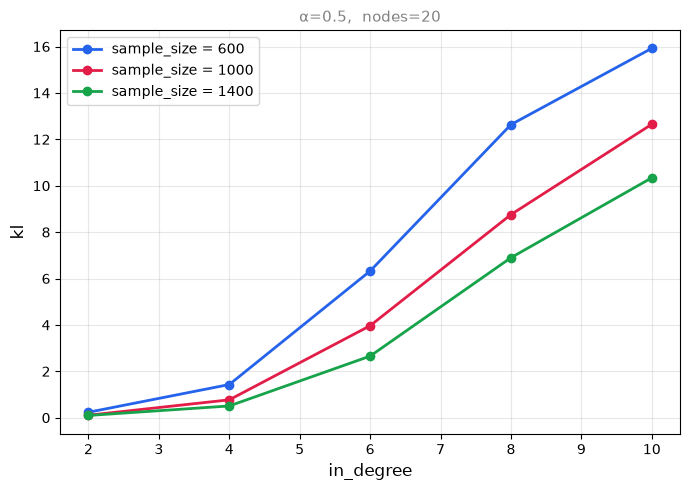

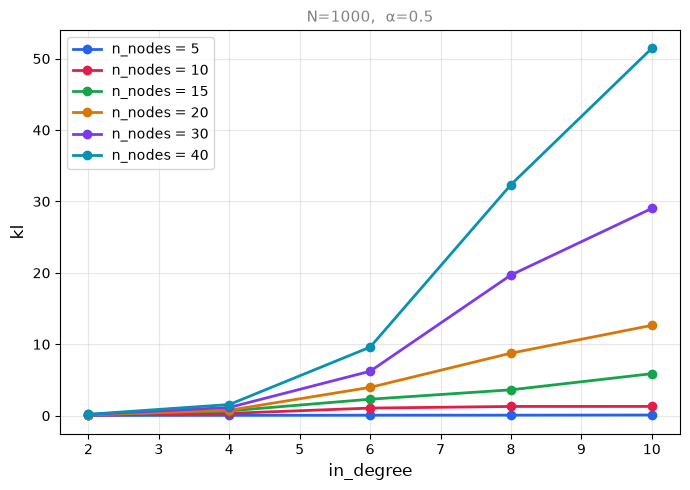

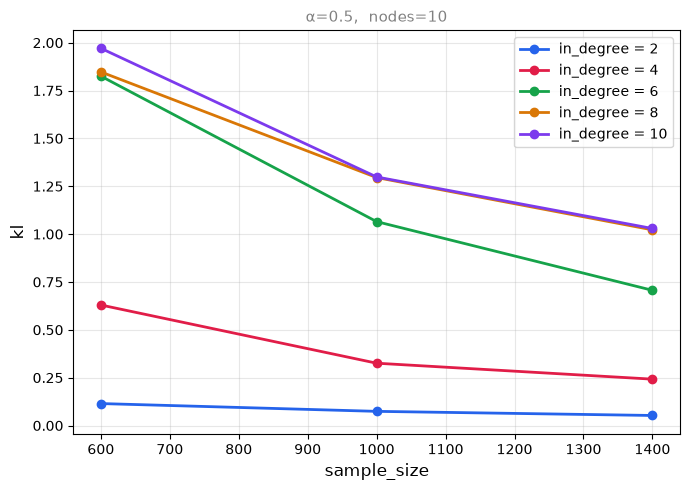

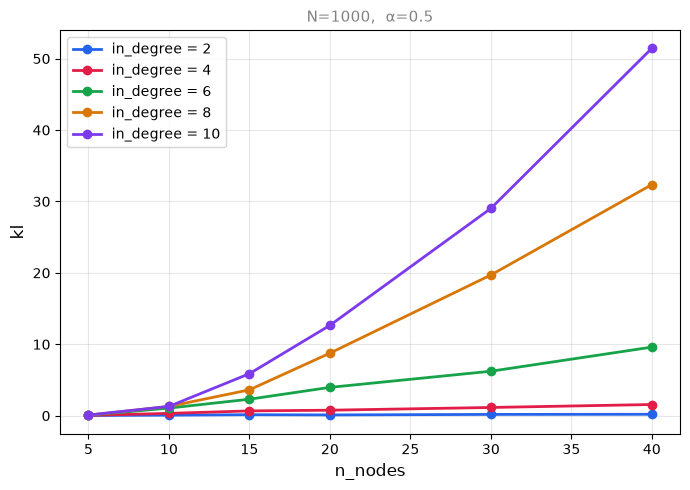

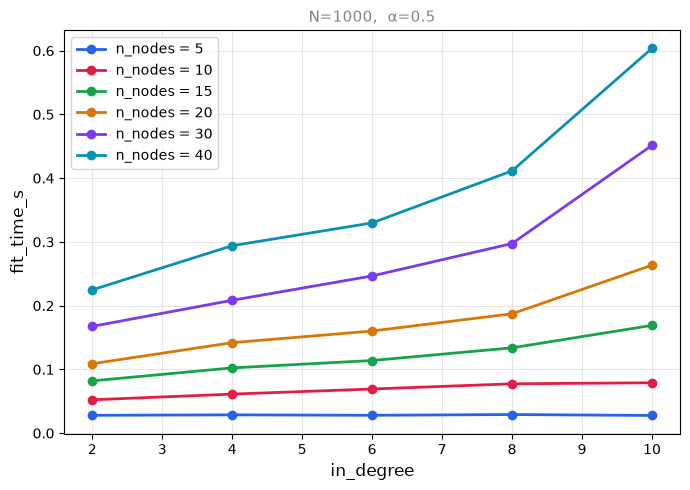

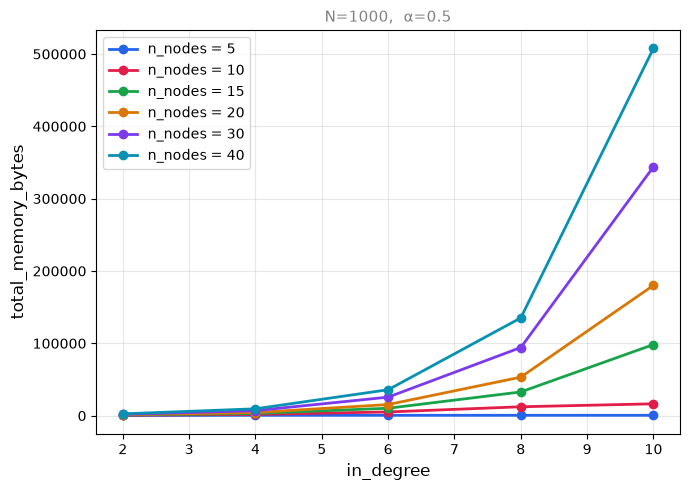

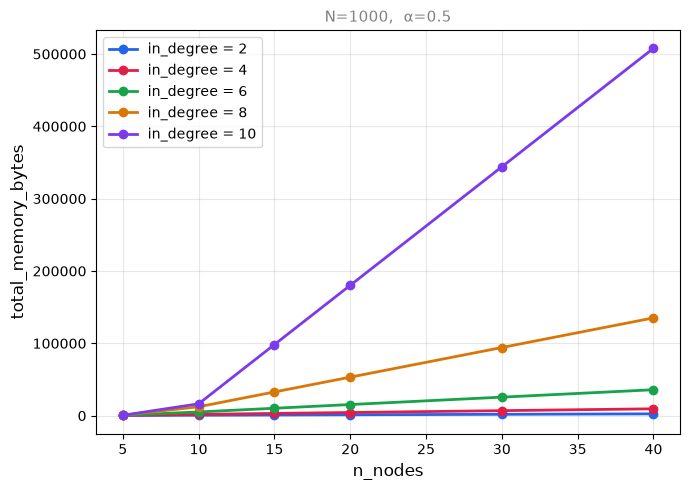

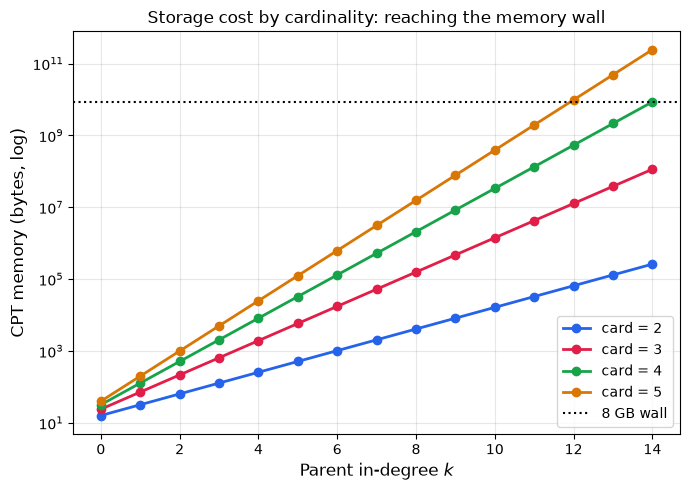

In [ ]:
df = pd.read_csv(f"{RESULTS_DIR}/results.csv")

plot_dir = os.path.join(RESULTS_DIR, "plots")
os.makedirs(plot_dir, exist_ok=True)

# (1)  KL vs in-degree, one curve per sample size
plot_grouped_curves(df, x="in_degree", hue="sample_size", y="kl", out_path="kl_vs_indegree_by_samplesize.png")
# (1b) same, grouped by network size
plot_grouped_curves(df, x="in_degree", hue="n_nodes", y="kl", out_path="kl_vs_indegree_by_n_nodes.png")
# (3)  KL vs sample size, one curve per in-degree
plot_grouped_curves(df, x="sample_size", hue="in_degree", y="kl", n_nodes=10, out_path="kl_vs_samplesize.png")
# (3b) KL vs network size, one curve per in-degree
plot_grouped_curves(df, x="n_nodes", hue="in_degree", y="kl", out_path="kl_vs_networksize.png")
# (5)  training time — turn OFF log-y since it's seconds, not divergence
plot_grouped_curves(df, x="in_degree", hue="n_nodes", y="fit_time_s", logy=False, out_path="training_time.png")
# (2)  memory vs in-degree with analytical overlay
plot_grouped_curves(df, x="in_degree", hue="n_nodes", y="total_memory_bytes", out_path="memory_vs_indegree")
# (2)  memory vs in-degree with analytical overlay
plot_grouped_curves(df, x="n_nodes", hue="in_degree", y="total_memory_bytes", out_path="memory_vs_n_nodes")
# (4)  cardinality wall
plot_cardinality_wall(cards=(2,3,4,5), max_k=14, wall_bytes=8*1024**3, out_path="fig4.png")